# Modelamiento Preeliminar : UrbanSafe AI

* **Curso:** Desarrollo de Productos de Datos (DS-3022) — UTEC
* **Ciclo:** 2026-II
* **Entrega:** Semana 06 — Exploratory Data Analysis and Model Selection
* **Integrantes:** Alessandro Monzón, Elmer Villegas y Juan Velo (lider).

1. Importamos los datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import time
import warnings
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import classification_report, f1_score, accuracy_score, mean_absolute_error, r2_score

2. Cargamos los datos

In [ ]:
warnings.filterwarnings('ignore')

CSV_PATH = "dataset_final_clima_transmilenio.csv"
df = pd.read_csv(CSV_PATH)

print(f"Dataset cargado correctamente: {df.shape[0]:,} filas x {df.shape[1]} columnas.")

Dataset cargado correctamente: 176,783 filas x 40 columnas.


In [ ]:
df

,num_est,Fecha,Hora,Linea,Tipo_Dia,Estacion,Latitud,Longitud,Ubicacion,Troncal,...,prcp,wspd,wdir,pres,cldc,wpgt,coco,clima_lluvia,clima_lluvia_cat,clima_temp_cat
0,2000,2026-07-01,4,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,...,NaN,7.0,60,1025.0,2,NaN,3,False,sin_lluvia,<12
1,2000,2026-07-01,5,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,...,NaN,6.0,50,1025.0,2,NaN,3,False,sin_lluvia,<12
2,2000,2026-07-01,6,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,...,NaN,5.0,90,1025.0,2,NaN,3,False,sin_lluvia,12-17
3,2000,2026-07-01,7,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,...,NaN,4.0,100,1026.0,6,NaN,3,False,sin_lluvia,12-17
4,2000,2026-07-01,8,(33) Zona B AutoNorte,Dia 1,(02000) Portal Norte - Unicervantes,4.754623,-74.046045,CL 173,Autopista Norte,...,0.0,7.0,110,1026.0,6,NaN,3,False,sin_lluvia,12-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176778,57503,2026-08-31,18,(30) Zona G NQS Sur,Dia 1,(57503) Ampliacion San Mateo,4.662607,-74.058714,NaN,NaN,...,0.0,8.0,110,1027.0,2,NaN,3,False,sin_lluvia,>17
176779,57503,2026-08-31,19,(30) Zona G NQS Sur,Dia 1,(57503) Ampliacion San Mateo,4.662607,-74.058714,NaN,NaN,...,0.0,7.0,140,1028.0,4,NaN,3,False,sin_lluvia,12-17
176780,57503,2026-08-31,20,(30) Zona G NQS Sur,Dia 1,(57503) Ampliacion San Mateo,4.662607,-74.058714,NaN,NaN,...,0.0,3.0,120,1029.0,2,NaN,2,False,sin_lluvia,12-17
176781,57503,2026-08-31,21,(30) Zona G NQS Sur,Dia 1,(57503) Ampliacion San Mateo,4.662607,-74.058714,NaN,NaN,...,0.0,3.0,340,1030.0,2,NaN,2,False,sin_lluvia,12-17


3. Definimos los Targets de nuestros modelos

In [ ]:
df["Fecha"] = pd.to_datetime(df["Fecha"])
df["Hora"] = df["Hora"].astype(int)

# Target 1A (Tiempo): Estimación del tiempo de paso en minutos (ETA)

df["Target_ETA_Min"] = np.where(df["Frecuencia"] > 0, 60.0 / df["Frecuencia"], df["Headway_Min"])

# IMPUTACIÓN Y LIMPIEZA DE NULOS EN TARGET ETA

df["Target_ETA_Min"] = df["Target_ETA_Min"].replace([np.inf, -np.inf], np.nan)

mediana_eta = df["Headway_Min"].median() if not np.isnan(df["Headway_Min"].median()) else 5.0

df["Target_ETA_Min"].fillna(mediana_eta, inplace=True)

df["Target_ETA_Min"] = df["Target_ETA_Min"].clip(lower=0.5, upper=45.0)

In [ ]:
# Target 1B (Aforo): Ocupación física real

df["Indice_Ocupacion"] = df["Validaciones"] / df["Cap_total"].replace(0, np.nan)

df["Indice_Ocupacion"].fillna(df["Indice_Ocupacion"].median(), inplace=True)

def categorizar_aforo_consistente(ocupacion):
    if ocupacion <= 0.40:
        return 0  # Bajo
    elif ocupacion <= 0.85:
        return 1  # Medio
    else:
        return 2  # Alto

df["Target_Aforo"] = df["Indice_Ocupacion"].apply(categorizar_aforo_consistente)

4. Realizamos Feature Engineering para obtener atributos que nos sirvan en el modelado

In [ ]:
df = df.sort_values(["num_est", "Fecha", "Hora"]).reset_index(drop=True)

# Lags históricos de demanda por estación

df["val_lag_1h"] = df.groupby("num_est")["Validaciones"].shift(1)

df["val_lag_24h"] = df.groupby("num_est")["Validaciones"].shift(24)

df["val_roll_mean_3h"] = df.groupby("num_est")["Validaciones"].transform(lambda x: x.shift(1).rolling(3).mean())

mediana_val = df["Validaciones"].median()

df["val_lag_1h"].fillna(mediana_val, inplace=True)

df["val_lag_24h"].fillna(mediana_val, inplace=True)

df["val_roll_mean_3h"].fillna(mediana_val, inplace=True)

In [ ]:
# Codificación transparente de categóricas

df["Troncal_code"] = df["Troncal"].astype("category").cat.codes

df["Franja_code"] = df["Franja"].astype("category").cat.codes

df["DiaSemana_code"] = df["DiaSemana"].astype("category").cat.codes

# Selección de Predictoras

features = [
    "Hora", "num_est", "Latitud", "Longitud", "Cap_total",
    "Frecuencia", "N_Rutas", "Sin_Oferta", "sin_capacidad",
    "Es_Habil", "Troncal_code", "Franja_code", "DiaSemana_code",
    "val_lag_1h", "val_lag_24h", "val_roll_mean_3h"
]

target_eta = "Target_ETA_Min"

target_aforo = "Target_Aforo"

5. Dividimos la data en test y train

In [ ]:
fecha_corte = pd.to_datetime("2026-08-13")

train_mask = df["Fecha"] < fecha_corte

test_mask = df["Fecha"] >= fecha_corte

X_train, X_test = df.loc[train_mask, features], df.loc[test_mask, features]

y_train_eta, y_test_eta = df.loc[train_mask, target_eta], df.loc[test_mask, target_eta]

y_train_aforo, y_test_aforo = df.loc[train_mask, target_aforo], df.loc[test_mask, target_aforo]

print(f"\nEntrenamiento: {X_train.shape[0]:,} muestras | Evaluación: {X_test.shape[0]:,} muestras")


Entrenamiento: 121,977 muestras | Evaluación: 54,806 muestras


6. Entrenamos los modelos seleccionados

In [ ]:
print("\n========================================================")
print("  MODELO 1A: PREDICTOR DE TIEMPO DE ESPERA (ETA)")
print("========================================================")

# Modelo A: Árbol de Regresión (Muy explicable e interpretable)

model_eta = DecisionTreeRegressor(max_depth=6, random_state=42)

model_eta.fit(X_train, y_train_eta)

preds_eta = model_eta.predict(X_test)

mae_eta = mean_absolute_error(y_test_eta, preds_eta)

r2_eta = r2_score(y_test_eta, preds_eta)

print(f"[Decision Tree Regressor]")
print(f"Error Absoluto Medio (MAE): {mae_eta:.2f} minutos")
print(f"Coeficiente R²:             {r2_eta:.4f}")


  MODELO 1A: PREDICTOR DE TIEMPO DE ESPERA (ETA)
[Decision Tree Regressor]
Error Absoluto Medio (MAE): 0.11 minutos
Coeficiente R²:             0.9131


In [ ]:
print("\n========================================================")
print("  MODELO 1B: PREDICTOR DE AFORO VEHICULAR")
print("========================================================")

# Modelo B: Random Forest Classifier

model_aforo = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)

model_aforo.fit(X_train, y_train_aforo)

preds_aforo = model_aforo.predict(X_test)

f1_aforo = f1_score(y_test_aforo, preds_aforo, average="macro")

acc_aforo = accuracy_score(y_test_aforo, preds_aforo)

print(f"[Random Forest Classifier]")
print(f"F1-Score Macro: {f1_aforo:.4f}")
print(f"Accuracy:       {acc_aforo:.4f}")


  MODELO 1B: PREDICTOR DE AFORO VEHICULAR
[Random Forest Classifier]
F1-Score Macro: 0.8177
Accuracy:       0.8832


In [ ]:
print("\n========================================================")
print("  MÓDULO 2: MOTOR PRESCRIPTIVO DE RECOMENDACIÓN")
print("========================================================")

# Matriz de Decisión Analítica explicable para la toma de decisiones:

# Si llega rápido (ETA corto), el usuario tolera viajar de pie (Aforo Medio)

def regla_usuario_analitica(aforo_pred, eta_pred_min):
    if aforo_pred == 0:
        return 0  # Abordar ahora (Asientos disponibles)

    elif aforo_pred == 1:  # Aforo Medio (Viaje de pie)
        if eta_pred_min <= 5.0:
            return 0  # Abordar ahora (Llega rápido, vale la pena ir de pie)
        else:
            return 1  # Esperar siguiente (Tarda un poco y viene gente de pie)

    else:  # Aforo Alto (Saturado)
        if eta_pred_min <= 3.0:
            return 1  # Esperar siguiente bus (El próximo viene muy pronto)
        else:
            return 2  # Evaluando alternativas / Trasladarse a otra troncal

y_rec_train = [regla_usuario_analitica(a, e) for a, e in zip(y_train_aforo, model_eta.predict(X_train))]

y_rec_test = [regla_usuario_analitica(a, e) for a, e in zip(y_test_aforo, preds_eta)]

dt_ranker = DecisionTreeClassifier(max_depth=4, random_state=42)

dt_ranker.fit(X_train, y_rec_train)

preds_rec = dt_ranker.predict(X_test)

print(f"Accuracy del Recomendador Analítico: {accuracy_score(y_rec_test, preds_rec):.4f}")


  MÓDULO 2: MOTOR PRESCRIPTIVO DE RECOMENDACIÓN
Accuracy del Recomendador Analítico: 0.9047


In [ ]:
print("\n========================================================")
print("  MÓDULO 4: DETECTOR DE ANOMALÍAS (ISOLATION FOREST)")
print("========================================================")

features_anomalia = ["Pax_bus", "Ocupacion_pk", "Headway_Min"]

X_anom = df[features_anomalia].fillna(0)

iso_forest = IsolationForest(contamination=0.015, n_estimators=200, random_state=42, n_jobs=-1)

iso_forest.fit(X_anom)

def categorizar_severidad_score(score):
    if score < -0.75:
        return "ANOMALÍA CRÍTICA (Bloqueo / Colapso Operativo)"
    elif score < -0.71:
        return "ALTA AFLUENCIA (Hora Pico / Operación Regular Intensa)"
    else:
        return "OPERACIÓN NORMAL"

df["Anomaly_Score"] = iso_forest.score_samples(X_anom)

df["Anomaly_Severity"] = df["Anomaly_Score"].apply(categorizar_severidad_score)

criticos = (df["Anomaly_Severity"].str.contains("CRÍTICA")).sum()

print(f"Alertas de Anomalía Crítica identificadas: {criticos:,} ({criticos/len(df)*100:.2f}%)")


  MÓDULO 4: DETECTOR DE ANOMALÍAS (ISOLATION FOREST)
Alertas de Anomalía Crítica identificadas: 700 (0.40%)


#### Evaluamos las métricas de nuestro modelo

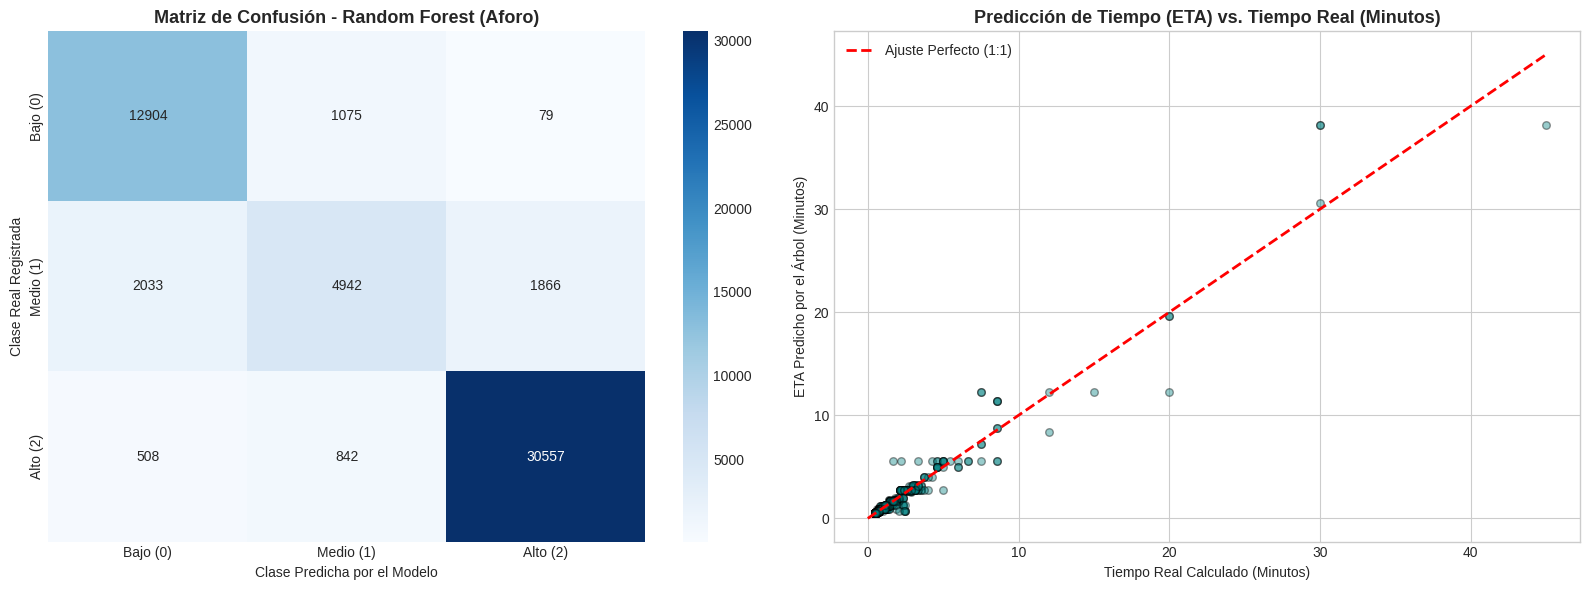

In [ ]:
plt.style.use("seaborn-v0_8-whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# A. MATRIZ DE CONFUSIÓN - MODELO 1B (AFORO)

cm_aforo = confusion_matrix(y_test_aforo, preds_aforo)

sns.heatmap(
    cm_aforo,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    xticklabels=["Bajo (0)", "Medio (1)", "Alto (2)"],
    yticklabels=["Bajo (0)", "Medio (1)", "Alto (2)"]
)

axes[0].set_title("Matriz de Confusión - Random Forest (Aforo)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Clase Predicha por el Modelo")
axes[0].set_ylabel("Clase Real Registrada")

# B. EVALUACIÓN DE REGRESIÓN - MODELO 1A (TIEMPO ETA)

# Muestreo representativo para evitar saturación gráfica en el scatter test

sample_indices = np.random.choice(len(y_test_eta), size=min(1500, len(y_test_eta)), replace=False)

y_test_sample = np.array(y_test_eta)[sample_indices]

preds_eta_sample = np.array(preds_eta)[sample_indices]

axes[1].scatter(y_test_sample, preds_eta_sample, alpha=0.4, color="teal", edgecolor="k", s=30)

# Línea ideal de predicción (y = x)

max_val = max(y_test_sample.max(), preds_eta_sample.max())

axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label="Ajuste Perfecto (1:1)")

axes[1].set_title("Predicción de Tiempo (ETA) vs. Tiempo Real (Minutos)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Tiempo Real Calculado (Minutos)")
axes[1].set_ylabel("ETA Predicho por el Árbol (Minutos)")
axes[1].legend(loc="upper left")

plt.tight_layout()
plt.show()


  MATRIZ DE TRANSICIÓN OPERATIVA (POR FRANJA HORARIA)


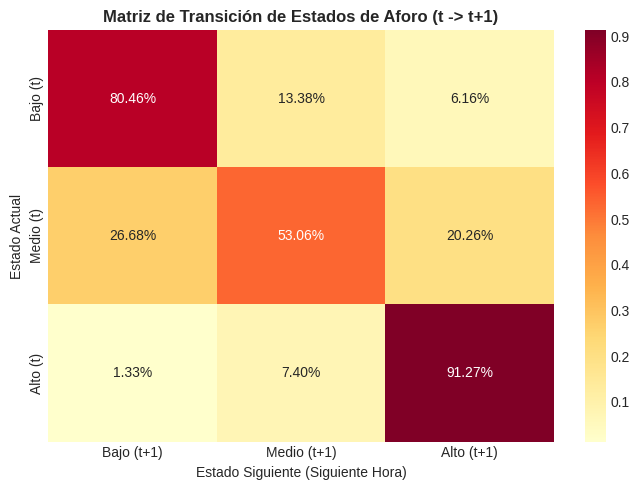

In [ ]:
# C. MATRIZ DE TRANSICIÓN DE AFORO (PROBABILIDAD PICO VS VALLE)

print("\n" + "="*65)
print("  MATRIZ DE TRANSICIÓN OPERATIVA (POR FRANJA HORARIA)")
print("="*65)

# Calculamos la matriz de transición de estados de aforo por hora

df_trans = df.copy()

df_trans['Aforo_Siguiente'] = df_trans.groupby('num_est')['Target_Aforo'].shift(-1)

trans_matrix = pd.crosstab(df_trans['Target_Aforo'], df_trans['Aforo_Siguiente'], normalize='index')

plt.figure(figsize=(7, 5))

sns.heatmap(
    trans_matrix,
    annot=True,
    fmt=".2%",
    cmap="YlOrRd",
    xticklabels=["Bajo (t+1)", "Medio (t+1)", "Alto (t+1)"],
    yticklabels=["Bajo (t)", "Medio (t)", "Alto (t)"]
)

plt.title("Matriz de Transición de Estados de Aforo (t -> t+1)", fontsize=12, fontweight="bold")
plt.xlabel("Estado Siguiente (Siguiente Hora)")
plt.ylabel("Estado Actual")
plt.tight_layout()
plt.show()

#### Probamos los modelos entrenados en casos posibles que pueden suceder en el Producto de Datos

In [ ]:
# Mapas de interpretación de clases y acciones

MAPA_AFORO = {
    0: "Bajo (Asientos Disponibles)",
    1: "Medio (Viaje de Pie)",
    2: "Alto (Bus Saturado)"
}

MAPA_RECOMENDACION = {
    0: "Abordar Ahora",
    1: "Esperar Siguiente Bus",
    2: "Trasladarse a Troncal Cercana"
}

In [ ]:
# CASOS DE PRUEBA

casos_integrados = [
    {
        "Estación / Ubicación": "Portal Américas (Hora Pico Mañana)",
        "Hora": 7, "num_est": 101, "Latitud": 4.628, "Longitud": -74.172,
        "Cap_total": 160, "Frecuencia": 45, "Headway_Min": 1.3, "N_Rutas": 8,
        "Sin_Oferta": 0, "sin_capacidad": 0, "Es_Habil": 1,
        "Troncal_code": 1, "Franja_code": 1, "DiaSemana_code": 1,
        "val_lag_1h": 320, "val_lag_24h": 310, "val_roll_mean_3h": 300,
        "Pax_bus": 35.0, "Ocupacion_pk": 8.5
    },
    {
        "Estación / Ubicación": "Marly (Hora Valle)",
        "Hora": 11, "num_est": 204, "Latitud": 4.646, "Longitud": -74.065,
        "Cap_total": 160, "Frecuencia": 20, "Headway_Min": 3.0, "N_Rutas": 5,
        "Sin_Oferta": 0, "sin_capacidad": 0, "Es_Habil": 1,
        "Troncal_code": 2, "Franja_code": 2, "DiaSemana_code": 2,
        "val_lag_1h": 85, "val_lag_24h": 90, "val_roll_mean_3h": 88,
        "Pax_bus": 12.0, "Ocupacion_pk": 2.1
    },
    {
        "Estación / Ubicación": "Heroínas / Av. Caracas (Bloqueo por Marcha)",
        "Hora": 17, "num_est": 305, "Latitud": 4.601, "Longitud": -74.072,
        "Cap_total": 160, "Frecuencia": 2, "Headway_Min": 30.0, "N_Rutas": 6,
        "Sin_Oferta": 1, "sin_capacidad": 1, "Es_Habil": 1,
        "Troncal_code": 2, "Franja_code": 1, "DiaSemana_code": 3,
        "val_lag_1h": 650, "val_lag_24h": 350, "val_roll_mean_3h": 500,
        "Pax_bus": 480.0, "Ocupacion_pk": 12.4
    },
    {
        "Estación / Ubicación": "Suba Rincón (Falla Mecánica de Flota)",
        "Hora": 18, "num_est": 402, "Latitud": 4.741, "Longitud": -74.085,
        "Cap_total": 160, "Frecuencia": 3, "Headway_Min": 20.0, "N_Rutas": 4,
        "Sin_Oferta": 1, "sin_capacidad": 1, "Es_Habil": 1,
        "Troncal_code": 3, "Franja_code": 1, "DiaSemana_code": 4,
        "val_lag_1h": 480, "val_lag_24h": 280, "val_roll_mean_3h": 380,
        "Pax_bus": 180.0, "Ocupacion_pk": 6.2
    },
    {
        "Estación / Ubicación": "Portal Norte (Madrugada / Cierre)",
        "Hora": 23, "num_est": 501, "Latitud": 4.754, "Longitud": -74.046,
        "Cap_total": 160, "Frecuencia": 5, "Headway_Min": 12.0, "N_Rutas": 2,
        "Sin_Oferta": 0, "sin_capacidad": 0, "Es_Habil": 1,
        "Troncal_code": 4, "Franja_code": 3, "DiaSemana_code": 5,
        "val_lag_1h": 15, "val_lag_24h": 20, "val_roll_mean_3h": 18,
        "Pax_bus": 5.0, "Ocupacion_pk": 0.4
    },
    {
        "Estación / Ubicación": "Calle 100 (Falso Reporte de Usuario)",
        "Hora": 14, "num_est": 210, "Latitud": 4.688, "Longitud": -74.058,
        "Cap_total": 160, "Frecuencia": 25, "Headway_Min": 2.4, "N_Rutas": 7,
        "Sin_Oferta": 0, "sin_capacidad": 0, "Es_Habil": 1,
        "Troncal_code": 2, "Franja_code": 2, "DiaSemana_code": 2,
        "val_lag_1h": 110, "val_lag_24h": 115, "val_roll_mean_3h": 112,
        "Pax_bus": 4.2, "Ocupacion_pk": 1.1
    }
]

df_casos = pd.DataFrame(casos_integrados)

In [ ]:
df_casos

,Estación / Ubicación,Hora,num_est,Latitud,Longitud,Cap_total,Frecuencia,Headway_Min,N_Rutas,Sin_Oferta,sin_capacidad,Es_Habil,Troncal_code,Franja_code,DiaSemana_code,val_lag_1h,val_lag_24h,val_roll_mean_3h,Pax_bus,Ocupacion_pk
0,Portal Américas (Hora Pico Mañana),7,101,4.628,-74.172,160,45,1.3,8,0,0,1,1,1,1,320,310,300,35.0,8.5
1,Marly (Hora Valle),11,204,4.646,-74.065,160,20,3.0,5,0,0,1,2,2,2,85,90,88,12.0,2.1
2,Heroínas / Av. Caracas (Bloqueo por Marcha),17,305,4.601,-74.072,160,2,30.0,6,1,1,1,2,1,3,650,350,500,480.0,12.4
3,Suba Rincón (Falla Mecánica de Flota),18,402,4.741,-74.085,160,3,20.0,4,1,1,1,3,1,4,480,280,380,180.0,6.2
4,Portal Norte (Madrugada / Cierre),23,501,4.754,-74.046,160,5,12.0,2,0,0,1,4,3,5,15,20,18,5.0,0.4
5,Calle 100 (Falso Reporte de Usuario),14,210,4.688,-74.058,160,25,2.4,7,0,0,1,2,2,2,110,115,112,4.2,1.1


Evaluación indivual de cada modelo

In [ ]:
# 1. Modelo 1A: Predicción de Tiempo (ETA en Minutos)
preds_eta_casos = model_eta.predict(df_casos[features])

# 2. Modelo 1B: Predicción de Aforo
preds_aforo_casos = model_aforo.predict(df_casos[features])

# 3. Modelo 2: Motor Prescriptivo de Recomendación
preds_rec_casos = dt_ranker.predict(df_casos[features])

# 4. Modelo 4: Detector de Anomalías
scores_anomalia_casos = iso_forest.score_samples(df_casos[features_anomalia])

In [ ]:
print("EVALUACIÓN DE CASOS POR CADA MODELO")

for i, fila in df_casos.iterrows():
    eta_val = preds_eta_casos[i]
    aforo_txt = MAPA_AFORO[preds_aforo_casos[i]]
    score = scores_anomalia_casos[i]
    anomalia_txt = categorizar_severidad_score(score)

    if "CRÍTICA" in anomalia_txt:
        rec_txt = "Trasladarse a Troncal Cercana (Operación Interrumpida)"
    else:
        rec_txt = MAPA_RECOMENDACION[preds_rec_casos[i]]

    print(f"\n [{fila['Estación / Ubicación']}]")
    print(f"   MODELO 1A (ETA Tiempo Espera):     {eta_val:.1f} minutos")
    print(f"   MODELO 1B (Aforo Predicho):        {aforo_txt}")
    print(f"   MODELO 2  (Recomendación Usuaria): {rec_txt}")
    print(f"   MODELO 4  (Estado Operativo):      {anomalia_txt} (Score: {score:.4f})")
    print("-" * 80)

EVALUACIÓN DE CASOS POR CADA MODELO

 [Portal Américas (Hora Pico Mañana)]
   MODELO 1A (ETA Tiempo Espera):     0.9 minutos
   MODELO 1B (Aforo Predicho):        Alto (Bus Saturado)
   MODELO 2  (Recomendación Usuaria): Esperar Siguiente Bus
   MODELO 4  (Estado Operativo):      OPERACIÓN NORMAL (Score: -0.7056)
--------------------------------------------------------------------------------

 [Marly (Hora Valle)]
   MODELO 1A (ETA Tiempo Espera):     2.8 minutos
   MODELO 1B (Aforo Predicho):        Medio (Viaje de Pie)
   MODELO 2  (Recomendación Usuaria): Abordar Ahora
   MODELO 4  (Estado Operativo):      OPERACIÓN NORMAL (Score: -0.5920)
--------------------------------------------------------------------------------

 [Heroínas / Av. Caracas (Bloqueo por Marcha)]
   MODELO 1A (ETA Tiempo Espera):     1.3 minutos
   MODELO 1B (Aforo Predicho):        Alto (Bus Saturado)
   MODELO 2  (Recomendación Usuaria): Trasladarse a Troncal Cercana (Operación Interrumpida)
   MODELO 4  (Esta